In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [ ]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

In [ ]:
snapshot_date = (
    df["TransactionStartTime"].max()
    + pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2019-02-14 10:01:28+0000', tz='UTC')

In [ ]:
print(snapshot_date)

2019-02-14 10:01:28+00:00


In [ ]:
rfm = (
    df.groupby("CustomerId")
    .agg(
        Recency=(
            "TransactionStartTime",
            lambda x: (
                snapshot_date - x.max()
            ).days
        ),
        Frequency=(
            "TransactionId",
            "count"
        ),
        Monetary=(
            "Value",  # use Value instead of Amount
            "sum"
        )
    )
    .reset_index()
)

rfm.head()

,CustomerId,Recency,Frequency,Monetary
0,CustomerId_1,84,1,10000
1,CustomerId_10,84,1,10000
2,CustomerId_1001,90,5,30400
3,CustomerId_1002,26,11,4775
4,CustomerId_1003,12,6,32000


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,3742.000000,3742.000000,3.742000e+03
mean,31.461251,25.564404,1.717377e+05
std,27.118932,96.929602,2.717305e+06
min,1.000000,1.000000,-1.049000e+08
25%,6.000000,2.000000,4.077438e+03
50%,25.000000,7.000000,2.000000e+04
75%,54.000000,20.000000,7.996775e+04
max,91.000000,4091.000000,8.345124e+07


### RFM Summary

Recency measures the number of days since a customer's most recent transaction. Frequency captures the total number of transactions performed by the customer, while Monetary measures the customer's cumulative transaction amount.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["cluster"] = kmeans.fit_predict(
    rfm_scaled
)

In [ ]:
rfm["cluster"].value_counts()

cluster
1    2312
0    1426
2       4
Name: count, dtype: int64

In [ ]:
rfm.groupby("cluster")[
["Recency", "Frequency", "Monetary"]
].mean()

,Recency,Frequency,Monetary
cluster,,,
0,61.877279,7.720196,8.973793e+04
1,12.715398,34.703720,2.247565e+05
2,23.250000,1104.500000,7.487659e+07


In [ ]:
rfm["cluster"].value_counts()

cluster
1    2312
0    1426
2       4
Name: count, dtype: int64

In [ ]:
rfm["is_high_risk"].value_counts()

is_high_risk
0    3741
1       1
Name: count, dtype: int64

In [ ]:
rfm["is_high_risk"] = (
    rfm["cluster"] == 0
).astype(int)

In [ ]:
rfm["is_high_risk"].value_counts()

is_high_risk
0    2316
1    1426
Name: count, dtype: int64

In [ ]:
rfm["is_high_risk"].value_counts(normalize=True)*100

is_high_risk
0    61.892036
1    38.107964
Name: proportion, dtype: float64

In [ ]:
target_df = rfm[
    ["CustomerId", "is_high_risk"]
]

target_df.head()

,CustomerId,is_high_risk
0,CustomerId_1,1
1,CustomerId_10,1
2,CustomerId_1001,1
3,CustomerId_1002,0
4,CustomerId_1003,0


In [ ]:
target_df.to_csv(
    "../data/processed/target.csv",
    index=False
)

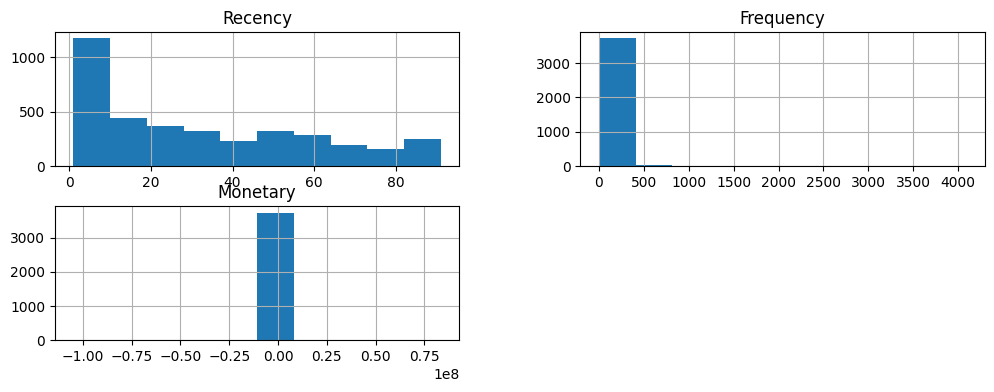

In [ ]:
rfm[["Recency","Frequency","Monetary"]].hist(
    figsize=(12,4)
)
plt.show()

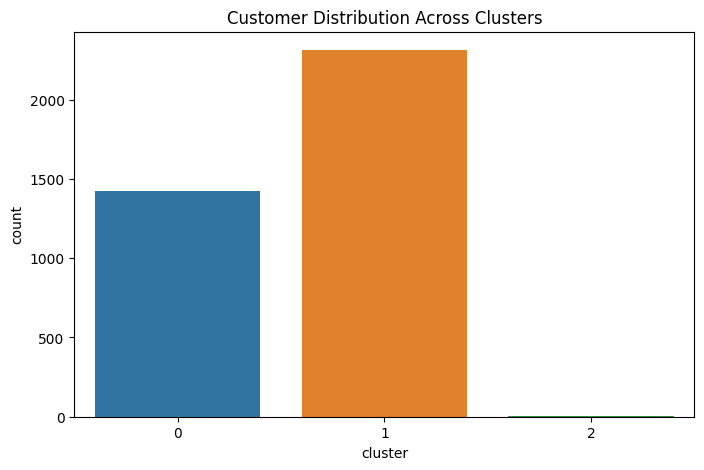

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(
    data=rfm,
    x="cluster"
)

plt.title(
    "Customer Distribution Across Clusters"
)

plt.show()

In [ ]:
cluster_summary = (
    rfm.groupby("cluster")
    [
        ["Recency",
         "Frequency",
         "Monetary"]
    ]
    .mean()
)

cluster_summary

,Recency,Frequency,Monetary
cluster,,,
0,61.877279,7.720196,8.973793e+04
1,12.715398,34.703720,2.247565e+05
2,23.250000,1104.500000,7.487659e+07


In [ ]:
df_target = df.merge(
    target_df,
    on="CustomerId",
    how="left"
)

In [ ]:
df_target["is_high_risk"].value_counts()

is_high_risk
0    84653
1    11009
Name: count, dtype: int64